# Examples 3D

The following showcases several examples of SpeedyWeather.jl simulating
the [Primitive equations](@ref primitive_equation_model) with and without
humidity and with and without physical parameterizations.

## The primitive equations model
The [primitive equations](https://en.wikipedia.org/wiki/Primitive_equations) are a hydrostatic approximation
of the compressible Navier-Stokes equations for an ideal gas on a rotating sphere. We largely follow
the idealised spectral dynamical core developed by GFDL[^GFDL1] and documented therein[^GFDL2].

The primitive equations solved by SpeedyWeather.jl for relative vorticity $\zeta$, divergence $\mathcal{D}$,
logarithm of surface pressure $\ln p_s$, temperature $T$ and specific humidity $q$ are:

$
\begin{aligned}
\frac{\partial \zeta}{\partial t} &= \nabla \times (\mathbf{\mathcal{P}}_\mathbf{u}
+ (f+\zeta)\mathbf{u}_\perp - W(\mathbf{u}) - R_dT_v\nabla \ln p_s) \\
\frac{\partial \mathcal{D}}{\partial t} &= \nabla \cdot (\mathcal{P}_\mathbf{u}
+ (f+\zeta)\mathbf{u}_\perp - W(\mathbf{u}) - R_dT_v\nabla \ln p_s) - \nabla^2(\frac{1}{2}(u^2 + v^2) + \Phi) \\
\frac{\partial \ln p_s}{\partial t} &= -\frac{1}{p_s} \nabla \cdot \int_0^{p_s} \mathbf{u}~dp \\
\frac{\partial T}{\partial t} &= \mathcal{P}_T -\nabla\cdot(\mathbf{u}T) + T\mathcal{D} - W(T) + \kappa T_v \frac{D \ln p}{Dt} \\
\frac{\partial q}{\partial t} &= \mathcal{P}_q -\nabla\cdot(\mathbf{u}q) + q\mathcal{D} - W(q)\\
\end{aligned}
$

The full description, including variable definitions and the solution algorithm is available here: [Primitive Equations in SpeedyWeather](https://speedyweather.github.io/SpeedyWeather.jl/dev/primitiveequation/)

See also [Examples 2D](https://speedyweather.github.io/SpeedyWeather.jl/dev/examples_2D/) for examples with the
[Barotropic vorticity equation](https://speedyweather.github.io/SpeedyWeather.jl/dev/barotropic/) and the
[shallow water model](https://speedyweather.github.io/SpeedyWeather.jl/dev/shallowwater/).

# Jablonowski-Williamson baroclinic wave
Please note that, now that we have 8 layers and more equations to solve, while T63 truncation looks very attractive for your final reporting, you will find that it runs too slowly on many of the older PCs. For initial development, **I strongly recommend that you start at T31 truncation**. You can always come back and re-run at T63, or even T127, when you are fully satisfied with your development(s).

In [1]:
using SpeedyWeather
spectral_grid = SpectralGrid(trunc=63, nlayers=8, Grid=FullGaussianGrid, dealiasing=3)

orography = ZonalRidge(spectral_grid)
initial_conditions = InitialConditions(
    vordiv = ZonalWind(),
    temp = JablonowskiTemperature(),
    pres = ZeroInitially())

model = PrimitiveDryModel(spectral_grid; orography, initial_conditions, physics=false)
simulation = initialize!(model)
run!(simulation, period=Day(9))

Weather is speedy: 100%|██████████████████| Time: 0:00:10 (212.19 years/day)


                      Surface relative vorticity [1/s]                       
       ┌────────────────────────────────────────────────────────────┐8.0f-5  
    90 │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ ┌──┐   
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│   
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│   
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│   
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│   
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│   
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│   
    ˚N │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│   
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│   
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│   
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄

The Jablonowski-Williamson baroclinic wave test case[^JW06] using the
[Primitive equation model](@ref primitive_equation_model) particularly the dry model,
as we switch off all physics with `physics=false`.
We want to use 8 vertical levels, and here PLV has used a truncation of T63, but it is recommended to start at a lower truncation of T31 on a
[full Gaussian grid](@ref FullGaussianGrid).
The Jablonowski-Williamson initial conditions are `ZonalWind` for vorticity and divergence
(curl and divergence of ``u, v``), `JablonowskiTemperature` for temperature and
`ZeroInitially` for pressure. The orography is just a `ZonalRidge`.
There is no forcing and the initial conditions are baroclinically unstable which kicks
off a wave propagating eastward. This wave becomes obvious when visualised with

In [2]:
using CairoMakie
vor = simulation.diagnostic_variables.grid.vor_grid[:, end]
fig=heatmap(vor, title="Surface relative vorticity")
save("jablonowski.png", fig)

![Jablonowski](jablonowski.png)

### Challenge on the J-W baroclinic instability problem
Use the example from the first notebook (GIWs and Equatorially traped waves) to save output to NetCDF, then create a sequence of PNG files, and animate. Produce an mp4 file that can be shown to your colleagues.

Question: what can you learn about the physics of this problem by watching the evolution of the flow in time?

*Exercise:* now insert Earth's orography and re-run the problem.
Questions:
- How does orography modify the evolution of the flow?
- Can you see any difference in the vorticity field?
- What happens in the Southern Hemisphere, and why?

## Held-Suarez forcing

In [95]:
#using SpeedyWeather
#spectral_grid = SpectralGrid(trunc=63, nlayers=8)
spectral_grid = SpectralGrid(trunc=511, nlayers=8)
output = NetCDFOutput(spectral_grid, PrimitiveDryModel, path="/Users/vidale/ShallowWaters", id="Held-Suarez", output_dt=Minute(60))
add!(output, SpeedyWeather.TemperatureOutput())  # output also temperature

# construct model with only Held-Suarez forcing, no other physics
model = PrimitiveDryModel(
    spectral_grid,

    # Held-Suarez forcing and drag
    temperature_relaxation = HeldSuarez(spectral_grid),
    boundary_layer_drag = LinearDrag(spectral_grid),

    # switch off other physics
    convection = NoConvection(),
    shortwave_radiation = NoShortwave(),
    longwave_radiation = NoLongwave(),
    vertical_diffusion = NoVerticalDiffusion(),

    # switch off surface fluxes (makes ocean/land/land-sea mask redundant)
    surface_wind = NoSurfaceWind(),
    surface_heat_flux = NoSurfaceHeatFlux(),

    # use Earth's orography
    orography = EarthOrography(spectral_grid),
    output=output
)

simulation = initialize!(model)
run!(simulation, period=Day(1),output=true)
nothing # hide

Weather is speedy: run 0004 100%|█████████| Time: 0:24:21 (59.02 days/day)


The code above defines the Held-Suarez forcing [^HS94] in terms of temperature relaxation
and a linear drag term that is applied near the planetary boundary but switches off
all other physics in the primitive equation model without humidity.
Switching off the surface wind would also automatically turn off the surface evaporation
(not relevant in the primitive _dry_ model) and sensible heat flux as that one is proportional
to the surface wind (which is zero with `NoSurfaceWind`).
But to also avoid the calculation being run at all we use `NoSurfaceHeatFlux()`
for the model constructor.
Many of the `NoSomething` model components do not require the
spectral grid to be passed on, but as a convention we allow every model component
to have it for construction even if not required.

Visualising surface temperature with this:

In [88]:
using CairoMakie
temp = simulation.diagnostic_variables.grid.temp_grid[:, end]
#temp = simulation.diagnostic_variables.grid.temp_grid[:, 1]
fig=heatmap(temp, title="Surface temperature [K]", colormap=:thermal)
save("heldsuarez.png", fig) # hide
nothing # hide

In [89]:
temp

10944-element, 96-ring OctahedralGaussianGrid{Float32}:
 247.04657
 246.28564
 245.39275
 244.42712
 243.45827
 242.5714
 241.88416
 241.53366
 241.62128
 242.15747
 243.05165
 244.14914
 245.28519
   ⋮
 229.82506
 230.02333
 230.31073
 230.62779
 230.90779
 231.10422
 231.2143
 231.28078
 231.35893
 231.4718
 231.58907
 231.63994

In [59]:
using NCDatasets
ds = NCDataset("/Users/vidale/ShallowWaters/run_0003/output.nc")
#ds["vor"]
ds["temp"]

temp (192 × 96 × 8 × 481)
  Datatype:    Union{Missing, Float32} (Float32)
  Dimensions:  lon × lat × layer × time
  Attributes:
   units                = degC
   long_name            = temperature
   _FillValue           = NaN


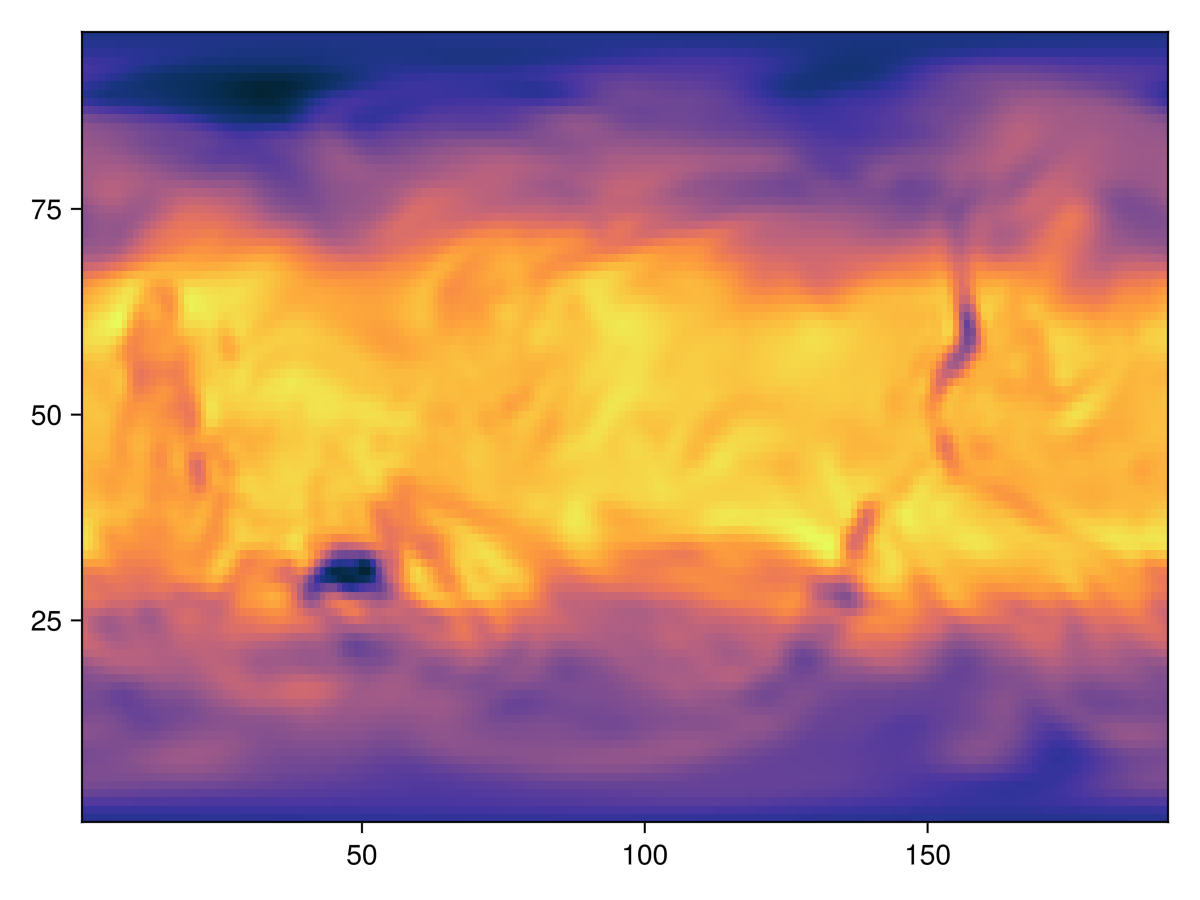

In [93]:
temptemp=ds["temp"]
temptemp
using CairoMakie
heatmap(temptemp[:,:, 4, end], colormap=:thermal)

In [94]:
temp = FullGaussianGrid(ds["temp"].var[:, :, :, :], input_as=Matrix)
temp

18432×8×481, 96-ring FullGaussianArray{Float32, 3, Array{Float32, 3}}:
[:, :, 1] =
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  -32.0312  -36.4688  -43.25  -48.75  -49.3125
 -71.125  -45.5312  -33.625  

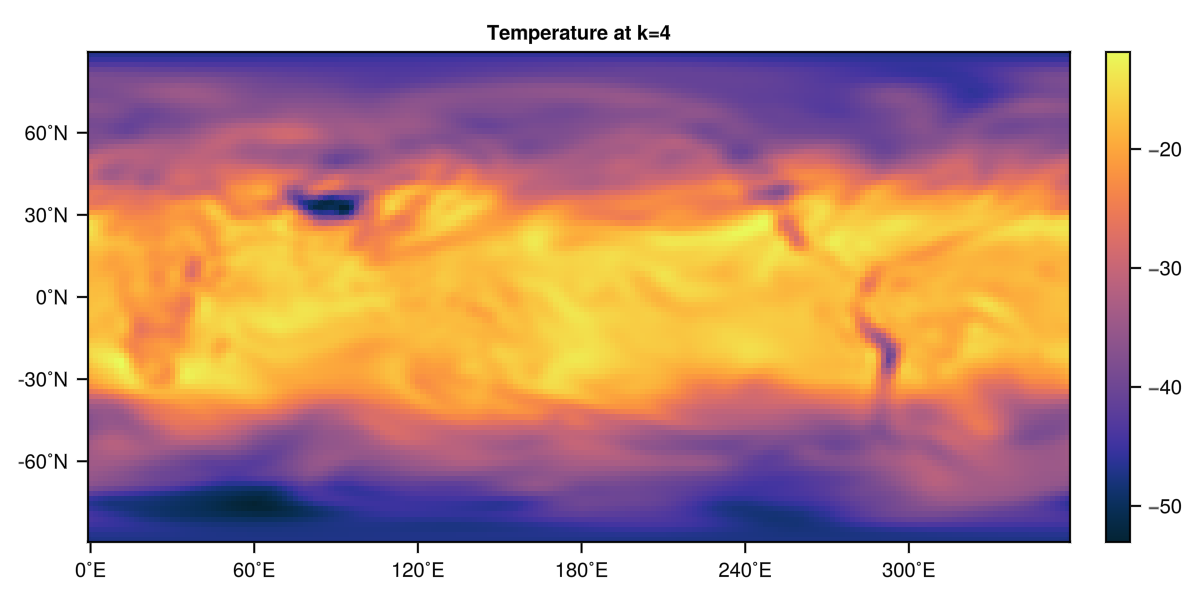

In [36]:
temp = FullGaussianGrid(ds["temp"].var[:, :, :, :], input_as=Matrix)
temp
using CairoMakie
heatmap(temp[:, 4, end], title="Temperature at k=4", colormap=:thermal)

![HeldSuarez](heldsuarez.png)

### Challenge on the Held-Suarez problem
Once again, save the output to NetCDF, then create a sequence of PNG files, and animate. Produce an mp4 file that can be shown to your colleagues.

Questions: 
- what is this test of the dynamical core designed to do?
- how is that objective achieved?
- what can you learn about the physics of this problem by watching the evolution of the flow in time?

## Aquaplanet
This is typically where weather and climate modellers will go next in understanding how good/bad their new dynamical core is. No complications from land/sea barriers, no empirical land surface parametrisations, just simple fluid dynamics and a few, carefully chosen instabilities.

In [5]:
using SpeedyWeather

# components
spectral_grid = SpectralGrid(trunc=63, nlayers=8)
ocean = AquaPlanet(spectral_grid, temp_equator=302, temp_poles=273)
land_sea_mask = AquaPlanetMask(spectral_grid)
orography = NoOrography(spectral_grid)

# create model, initialize, run
model = PrimitiveWetModel(spectral_grid; ocean, land_sea_mask, orography)
simulation = initialize!(model)
run!(simulation, period=Day(20))
nothing # hide

Weather is speedy: 100%|██████████████████| Time: 0:00:29 (159.37 years/day)


Here we have defined an aquaplanet simulation by
- creating an `ocean::AquaPlanet`. This will use constant sea surface temperatures that only vary with latitude.
- creating a `land_sea_mask::AquaPlanetMask` this will use a land-sea mask with `false`=ocean everywhere.
- creating an `orography::NoOrography` which will have no orography and zero surface geopotential.

All passed on to the model constructor for a `PrimitiveWetModel`, we have now a model with humidity
and physics parameterization as they are defined by default (typing `model` will give you an overview
of its components). We could have change the `model.land` and `model.vegetation` components too,
but given the land-sea masks masks those contributions to the surface fluxes anyway, this is not
necessary. Note that neither sea surface temperature, land-sea mask
or orography have to agree. It is possible to have an ocean on top of a mountain.
For an ocean grid-cell that is (partially) masked by the land-sea mask, its value will
be (fractionally) ignored in the calculation of surface fluxes (potentially leading
to a zero flux depending on land surface temperatures).

Now with the following we visualize the surface humidity after the 50 days of
simulation. We use 50 days as without mountains it takes longer for the initial conditions to
become unstable. The surface humidity shows small-scale patches in the tropics, which is a result
of the convection scheme, causing updrafts and downdrafts in both humidity and temperature.

In [6]:
#using CairoMakie
humid = simulation.diagnostic_variables.grid.humid_grid[:, end]
fig=heatmap(humid, title="Surface specific humidity [kg/kg]", colormap=:oslo)
save("aquaplanet.png", fig) # hide
nothing # hide

![Aquaplanet](aquaplanet.png)

## Aquaplanet without (deep) convection
Now we want to compare the previous simulation to a simulation without
deep convection, called `DryBettsMiller`, because it is the
[Betts-Miller convection](@ref BettsMiller) but with humidity set to zero
in which case the convection is always non-precipitating _shallow_
(because the missing latent heat release from condensation makes it shallower)
convection. In fact, this convection is the default when using
the `PrimitiveDryModel`. Instead of redefining the [Aquaplanet](@ref) setup again,
we simply reuse these components `spectral_grid`, `ocean`, `land_sea_mask`
and `orography` (because `spectral_grid` hasn't changed this is possible).

In [7]:
# Execute the code from Aquaplanet above first!
convection = DryBettsMiller(spectral_grid, time_scale=Hour(4))

# reuse other model components from before
model = PrimitiveWetModel(spectral_grid; ocean, land_sea_mask, orography, convection)

simulation = initialize!(model)
run!(simulation, period=Day(20))

humid = simulation.diagnostic_variables.grid.humid_grid[:, end]
fig=heatmap(humid, title="No deep convection: Surface specific humidity [kg/kg]", colormap=:oslo)
save("aquaplanet_nodeepconvection.png", fig) # hide
nothing # hide

Weather is speedy: 100%|██████████████████| Time: 0:00:26 (176.56 years/day)


![Aquaplanet, no deep convection](aquaplanet_nodeepconvection.png)

But we also want to compare this to a setup where convection is completely
disabled, i.e. `convection = NoConvection()` (many of the `No` model components
don't require the `spectral_grid` to be passed on, but some do!)

In [8]:
# Execute the code from Aquaplanet above first!
convection = NoConvection(spectral_grid)

# reuse other model components from before
model = PrimitiveWetModel(spectral_grid; ocean, land_sea_mask, orography, convection)

simulation = initialize!(model)
run!(simulation, period=Day(20))

humid = simulation.diagnostic_variables.grid.humid_grid[:, end]
fig=heatmap(humid, title="No convection: Surface specific humidity [kg/kg]", colormap=:oslo)
save("aquaplanet_noconvection.png", fig) # hide
nothing # hide

Weather is speedy: 100%|██████████████████| Time: 0:00:25 (184.88 years/day)


And the comparison looks like

![Aquaplanet, no deep convection](aquaplanet_nodeepconvection.png)
![Aquaplanet, no convection](aquaplanet_noconvection.png)


## Large-scale vs convective precipitation

In [9]:
using SpeedyWeather

# components
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
large_scale_condensation = ImplicitCondensation(spectral_grid)
convection = SimplifiedBettsMiller(spectral_grid)

# create model, initialize, run
model = PrimitiveWetModel(spectral_grid; large_scale_condensation, convection)
simulation = initialize!(model)
run!(simulation, period=Day(10))
nothing # hide

Weather is speedy: 100%|██████████████████| Time: 0:00:01 (1503.10 years/day)


We run the default `PrimitiveWetModel` with `ImplicitCondensation` as large-scale condensation
(see [Implicit large-scale condensation](@ref)) and the `SimplifiedBettsMiller`
for convection (see [Simplified Betts-Miller](@ref BettsMiller)). These schemes
have some additional parameters, we leave them as default for now, but you could
do `ImplicitCondensation(spectral_grid, relative_humidity_threshold = 0.8)` to
let it rain at 80% instead of 100% relative humidity. We now want to analyse
the precipitation that comes from these parameterizations


In [10]:
using CairoMakie

(; precip_large_scale, precip_convection) = simulation.diagnostic_variables.physics
m2mm = 1000     # convert from [m] to [mm]
fig=heatmap(m2mm*precip_large_scale, title="Large-scale precipiation [mm]: Accumulated over 10 days", colormap=:dense)
save("large-scale_precipitation_acc.png", fig) # hide
nothing # hide

![Large-scale precipitation](large-scale_precipitation_acc.png)


Precipitation (both large-scale and convective) are written into the
`simulation.diagnostic_variables.physics` which, however, accumulate all precipitation
during simulation. In the NetCDF output, precipitation rate (in mm/hr) is calculated
from accumulated precipitation as a post-processing step.
More interactively, you can also reset these accumulators and integrate for another 6 hours
to get the precipitation only in that period.

In [11]:
# reset accumulators and simulate 6 hours
simulation.diagnostic_variables.physics.precip_large_scale .= 0
simulation.diagnostic_variables.physics.precip_convection .= 0
run!(simulation, period=Hour(6))

# visualise, precip_* arrays are flat copies, no need to read them out again!
m2mm_hr = (1000*Hour(1)/Hour(6))    # convert from [m] to [mm/hr]
fig=heatmap(m2mm_hr*precip_large_scale, title="Large-scale precipiation [mm/hr]", colormap=:dense)
save("large-scale_precipitation.png", fig) # hide
fig2=heatmap(m2mm_hr*precip_convection, title="Convective precipiation [mm/hr]", colormap=:dense)
save("convective_precipitation.png", fig2) # hide
nothing # hide


As the precipitation fields are accumulated meters over the integration period
we divide by 6 hours to get a precipitation rate ``[m/s]``
but then multiply with 1 hour and 1000 to get the typical precipitation unit of ``[mm/hr]``.

![Large-scale precipitation](large-scale_precipitation.png)


![Convective precipitation](convective_precipitation.png)

## References

[^JW06]: Jablonowski, C. and Williamson, D.L. (2006), A baroclinic instability test case for atmospheric model dynamical cores. Q.J.R. Meteorol. Soc., 132: 2943-2975. DOI:[10.1256/qj.06.12](https://doi.org/10.1256/qj.06.12)

[^HS94]: Held, I. M. & Suarez, M. J. A Proposal for the Intercomparison of the Dynamical Cores of Atmospheric General Cir